<a href="https://colab.research.google.com/github/OCHERDENE-web/wed_2026_bigdatacomputing/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  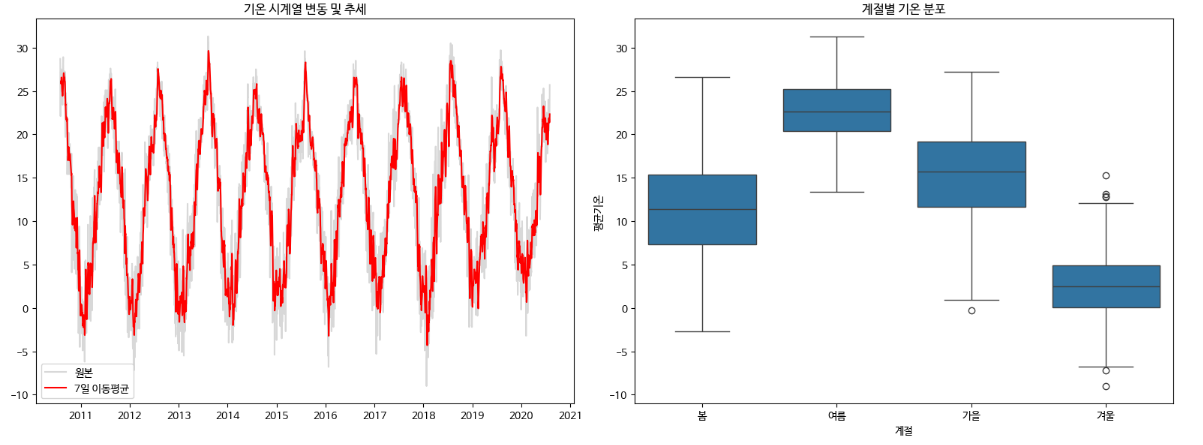

  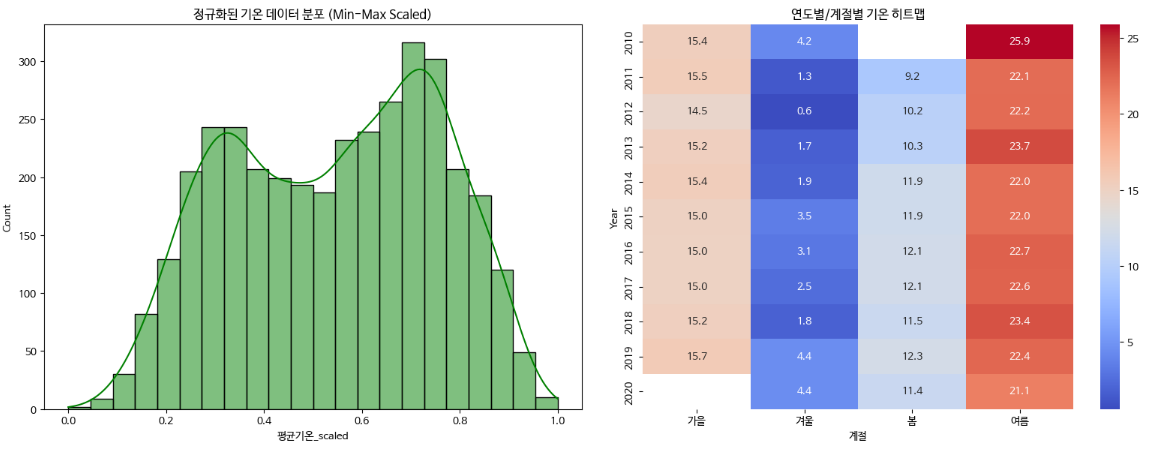



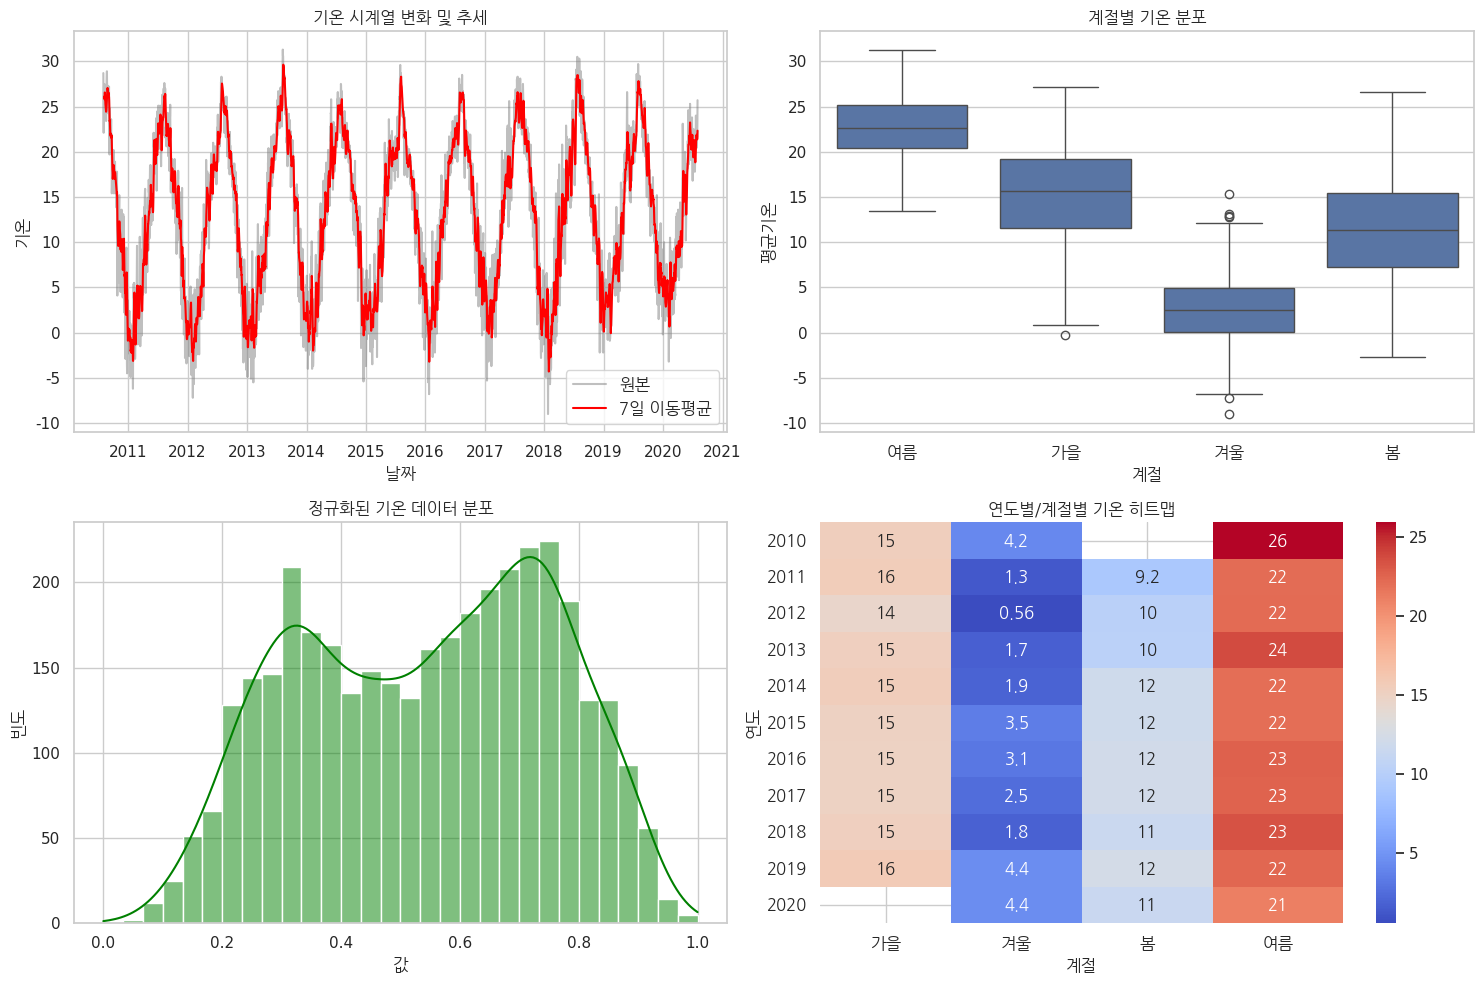

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import matplotlib.font_manager as fm

# 1. 환경 설정 (한글 폰트)
warnings.filterwarnings('ignore')

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

if not os.path.exists(font_path):
    import subprocess
    subprocess.run(['apt-get','update'])
    subprocess.run(['apt-get','install','-y','fonts-nanum'])

font_prop = fm.FontProperties(fname=font_path)

# 2. 데이터 불러오기
url = "https://github.com/dongupak/DataML/raw/main/csv/weather.csv"
df = pd.read_csv(url, encoding='cp949')

# 3. 전처리
df.columns = df.columns.str.strip()
df['일시'] = pd.to_datetime(df['일시'])
df = df.sort_values('일시')
df.set_index('일시', inplace=True)

# 4. 계절 생성
def get_season(m):
    if m in [3,4,5]:
        return '봄'
    elif m in [6,7,8]:
        return '여름'
    elif m in [9,10,11]:
        return '가을'
    else:
        return '겨울'

df['계절'] = df.index.month.map(get_season)

# 5. 이동평균
df['이동평균'] = df['평균기온'].rolling(7).mean()

# 6. 정규화
df['scaled'] = (df['평균기온'] - df['평균기온'].min()) / (df['평균기온'].max() - df['평균기온'].min())

# 7. 피벗
df['연도'] = df.index.year
pivot = df.pivot_table(values='평균기온', index='연도', columns='계절', aggfunc='mean')

# 8. 그래프
plt.figure(figsize=(15,10))

# (1) 시계열
plt.subplot(2,2,1)
plt.plot(df.index, df['평균기온'], color='gray', alpha=0.5, label='원본')
plt.plot(df.index, df['이동평균'], color='red', label='7일 이동평균')
plt.title('기온 시계열 변화 및 추세', fontproperties=font_prop)
plt.xlabel('날짜', fontproperties=font_prop)
plt.ylabel('기온', fontproperties=font_prop)
plt.legend(prop=font_prop)

# (2) 박스플롯
plt.subplot(2,2,2)
sns.boxplot(x='계절', y='평균기온', data=df)
plt.title('계절별 기온 분포', fontproperties=font_prop)
plt.xlabel('계절', fontproperties=font_prop)
plt.ylabel('평균기온', fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)  # 🔥 계절 글자

# (3) 히스토그램
plt.subplot(2,2,3)
sns.histplot(df['scaled'], bins=30, kde=True, color='green')
plt.title('정규화된 기온 데이터 분포', fontproperties=font_prop)
plt.xlabel('값', fontproperties=font_prop)
plt.ylabel('빈도', fontproperties=font_prop)

# (4) 히트맵
plt.subplot(2,2,4)
sns.heatmap(
    pivot,
    annot=True,
    cmap='coolwarm',
    annot_kws={"fontproperties": font_prop}
)

plt.title('연도별/계절별 기온 히트맵', fontproperties=font_prop)

# 🔥 axis + tick фонт
plt.xlabel('계절', fontproperties=font_prop)
plt.ylabel('연도', fontproperties=font_prop)
plt.xticks(fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
